In [29]:
# !pip install torchsummary
# !pip install pytorch-ignite

In [30]:
# !pip install shap

In [31]:
# # Installa PyTorch con supporto MPS
# !pip install torch torchvision torchaudio

# NN Pytorch - titletype - 2 HIDDEN LAYER (64, 32)

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch
import torch.nn.functional as F
import shap
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from torchsummary import summary
from torch.nn.init import xavier_normal_
from torch.utils.data import TensorDataset, DataLoader

from ignite.metrics import MeanSquaredError, MeanAbsoluteError, Metric

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from ignite.metrics import Accuracy, Loss
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator

### Import dati

In [35]:
x_train = (pd.read_csv('../../title/X_train_title_no_out.csv')).drop('Unnamed: 0', axis =1)
y_train = (pd.read_csv('../../title/y_train_title_no_out.csv')).drop('Unnamed: 0', axis =1)

x_test = (pd.read_csv('../../title/X_test_title.csv')).drop('Unnamed: 0', axis =1)
y_test = (pd.read_csv('../../title/y_test_title.csv')).drop('Unnamed: 0', axis =1)

In [36]:
y_train = y_train['title_type']
y_test = y_test['title_type']

In [37]:
# log transformation delle seguenti colonne: runtimeminutes, numvotes, totalcredits, userrewtotal, totalmedia
cols = ['runtimeMinutes', 'numVotes', 'totalCredits', 'userReviewsTotal', 'totalMedia']

for col in cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])

In [38]:
scaler = StandardScaler()

num_cols = ['startYear', 'runtimeMinutes', 'numVotes', 'totalCredits', 'criticReviewsTotal', 'numRegions', 'userReviewsTotal',
        'companiesNumber', 'externalLinks', 'writerCredits',
        'directorsCredits', 'quotesTotal', 'totalMedia', 'totalNominations']

scaler.fit(x_train[num_cols])
x_train[num_cols] = scaler.transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

### Costruzione rete

In [39]:
x_train_split, x_val, y_train_split, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=42)

In [40]:
x_train_tensor = torch.tensor(x_train_split.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split.values, dtype=torch.long)

x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.long)

x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [41]:
# Conta quanti esempi ci sono per ogni classe
class_counts = torch.bincount(y_train_tensor)
class_weights = 1.0 / class_counts.float()

# Assegna a ciascun campione il peso della sua classe
sample_weights = class_weights[y_train_tensor]

# Crea il sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # numero di campioni da estrarre per epoch
    replacement=True
)

In [42]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [43]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

In [44]:
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [45]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='cpu')

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NNClassifier(nn.Module):

    def __init__(self,
                 input_dim, output_size
                , dropout_prob=0.03
                 ):
        super(NNClassifier, self).__init__()

        self.hidden1 = nn.Linear(input_dim, 128)
        self.hidden2 = nn.Linear(128, 64)
        self.output_layer = nn.Linear(64, output_size)

        self.relu = nn.ReLU()
        # self.tahn = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout_prob)  # Dropout layer

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        # x = self.tahn(self.hidden1(x))
        x = self.dropout(x)          # Applica Dropout dopo il primo hidden layer
        x = self.relu(self.hidden2(x))
        # x = self.tahn(self.hidden2(x))
        x = self.dropout(x)          # Applica Dropout dopo il secondo hidden layer
        x = self.output_layer(x)     # Output logits (CrossEntropyLoss gestisce Softmax)
        return x


In [47]:
input_size = x_train.shape[1] # ci devono essere tanti neuroni quante colonne da considerare
output_size = 10 # settato ad 10 perché l'output della classificazione sono 10 classi

In [48]:
from ignite.handlers import EarlyStopping, ModelCheckpoint
from ignite.contrib.handlers import global_step_from_engine
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Precision, Recall, ConfusionMatrix, Fbeta


In [49]:
# import torch
# import numpy as np

# # Conta quante volte compare ciascuna classe
# class_counts = torch.bincount(y_train_tensor)   # y_train è un torch.Tensor di interi (etichette)
# class_weights = 1.0 / class_counts.float()
# class_weights = class_weights / class_weights.sum()  # normalizza per sicurezza

# # Trasforma in tensore da passare alla loss
# class_weights_tensor = class_weights.to(device)


In [50]:
model = NNClassifier(input_size, output_size)
optimizer = optim.SGD(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()


In [51]:
trainer = create_supervised_trainer(model, optimizer, criterion, device)

In [52]:
val_metrics = {
    "accuracy": Accuracy(),
    "f1_macro": Fbeta(beta=1.0, average=True),
    "loss": Loss(criterion)
}

train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

# --- Storico ---
training_history = {m: [] for m in val_metrics.keys()}
validation_history = {m: [] for m in val_metrics.keys()}

In [53]:
@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics

    training_history['loss'].append(metrics['loss'])
    training_history['accuracy'].append(metrics['accuracy'])
    training_history['f1_macro'].append(metrics['f1_macro'])

    print(f"Training Results - Epoch[{trainer.state.epoch}] "
          f"Loss: {metrics['loss']:.4f} "
          f"Acc: {metrics['accuracy']:.4f} "
          f"F1(macro): {metrics['f1_macro']:.4f}")


@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics

    validation_history['loss'].append(metrics['loss'])
    validation_history['accuracy'].append(metrics['accuracy'])
    validation_history['f1_macro'].append(metrics['f1_macro'])

    print(f"Validation Results - Epoch[{trainer.state.epoch}] "
          f"Loss: {metrics['loss']:.4f} "
          f"Acc: {metrics['accuracy']:.4f} "
          f"F1(macro): {metrics['f1_macro']:.4f}")


In [54]:
from ignite.metrics import Accuracy

# Assicurati di avere f1 calcolata nel val_evaluator
def score_function(engine):
    metrics = engine.state.metrics
    return metrics['f1_macro']  # EarlyStopping massimizza questa metrica

In [55]:
handler = EarlyStopping(patience=50, score_function=score_function, trainer=trainer)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# Per ReduceLROnPlateau devi gestire lo scheduler manualmente
# perché ha bisogno di una metrica per decidere quando ridurre il LR
@val_evaluator.on(Events.EPOCH_COMPLETED)
def scheduler_step(engine):
    # Ottieni la loss di validazione dalle metriche
    val_loss = engine.state.metrics['loss']
    scheduler.step(val_loss)

@trainer.on(Events.EPOCH_COMPLETED)
def print_lr(engine):
    print("Learning Rate:", optimizer.param_groups[0]['lr'])

checkpoint = ModelCheckpoint(
    dirname='models',
    filename_prefix='best_EARLY',
    n_saved=1,
    create_dir=True,
    global_step_transform=global_step_from_engine(trainer),
    require_empty=False
)

val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, handler)
val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, checkpoint, {'model': model})

In [56]:
trainer.run(train_loader, max_epochs=100)

Training Results - Epoch[1] Loss: 2.2119 Acc: 0.2536 F1(macro): 0.1932
Validation Results - Epoch[1] Loss: 2.2488 Acc: 0.0491 F1(macro): 0.0707
Learning Rate: 0.001
Training Results - Epoch[2] Loss: 2.0297 Acc: 0.3547 F1(macro): 0.3003
Validation Results - Epoch[2] Loss: 2.0961 Acc: 0.2167 F1(macro): 0.1494
Learning Rate: 0.001
Training Results - Epoch[3] Loss: 1.8172 Acc: 0.3944 F1(macro): 0.3620
Validation Results - Epoch[3] Loss: 1.8993 Acc: 0.3673 F1(macro): 0.2214
Learning Rate: 0.001
Training Results - Epoch[4] Loss: 1.6407 Acc: 0.4624 F1(macro): 0.4349
Validation Results - Epoch[4] Loss: 1.6706 Acc: 0.5438 F1(macro): 0.3060
Learning Rate: 0.001
Training Results - Epoch[5] Loss: 1.4884 Acc: 0.4891 F1(macro): 0.4687
Validation Results - Epoch[5] Loss: 1.5329 Acc: 0.5545 F1(macro): 0.3283
Learning Rate: 0.001
Training Results - Epoch[6] Loss: 1.3654 Acc: 0.5195 F1(macro): 0.5002
Validation Results - Epoch[6] Loss: 1.3786 Acc: 0.6013 F1(macro): 0.3575
Learning Rate: 0.001
Training R

State:
	iteration: 222400
	epoch: 100
	epoch_length: 2224
	max_epochs: 100
	output: 0.8892995119094849
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

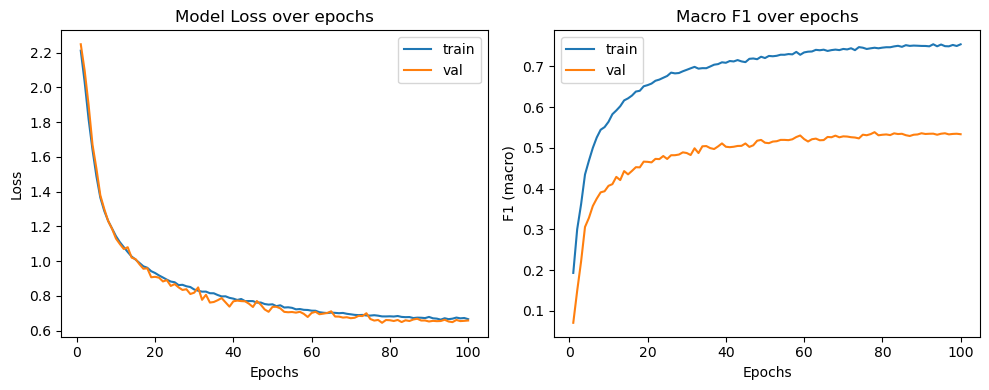

In [57]:
import matplotlib.pyplot as plt

epochs = range(1, len(training_history['loss']) + 1)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# --- Plot Model Loss ---
axes[0].plot(epochs, training_history['loss'], label='train')
axes[0].plot(epochs, validation_history['loss'], label='val')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss over epochs')
axes[0].legend()

# --- Plot Macro F1 ---
axes[1].plot(epochs, training_history['f1_macro'], label='train')
axes[1].plot(epochs, validation_history['f1_macro'], label='val')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1 (macro)')
axes[1].set_title('Macro F1 over epochs')
axes[1].legend()

fig.tight_layout()
plt.show()


### VALIDATION

In [58]:
model.eval()  # importantissimo: disabilita dropout e batchnorm

NNClassifier(
  (hidden1): Linear(in_features=50, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.03, inplace=False)
)

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

NNClassifier(
  (hidden1): Linear(in_features=50, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.03, inplace=False)
)

In [60]:
with torch.no_grad():  # disabilita il calcolo dei gradienti
    logits = model(x_val_tensor)          # output layer, logits
    probs = torch.softmax(logits, dim=1)  # probabilità
    preds = torch.argmax(probs, dim=1)    # classe predetta

In [61]:
probs = probs.cpu().numpy()
preds = preds.cpu().numpy()

In [62]:
report = classification_report(y_val, preds)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.71      0.81      7175
           1       0.91      0.80      0.85      3532
           2       0.98      0.82      0.89     14666
           3       0.26      0.65      0.37       342
           4       0.27      0.62      0.37      1220
           5       0.67      0.76      0.71      1865
           6       0.04      0.59      0.07        54
           7       0.17      0.75      0.27       234
           8       0.46      0.50      0.48      1055
           9       0.36      0.86      0.51       353

    accuracy                           0.77     30496
   macro avg       0.50      0.71      0.53     30496
weighted avg       0.87      0.77      0.80     30496



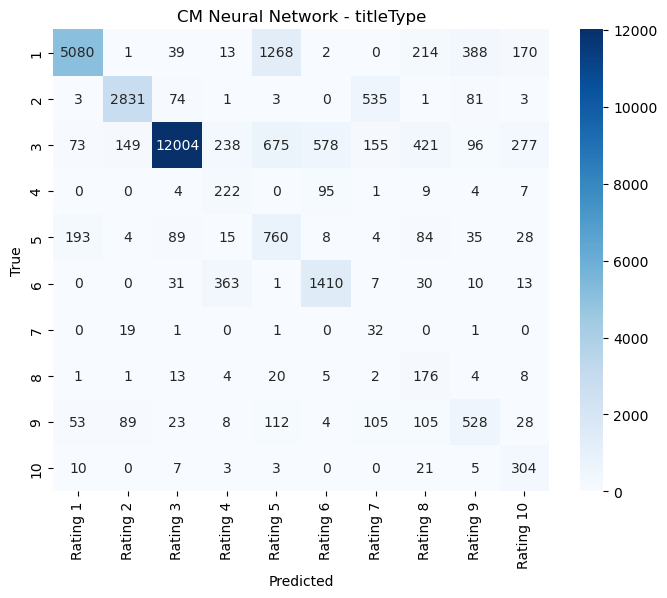

In [63]:
cm = confusion_matrix(y_val, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Rating {i}' for i in range(1, 11)],
            yticklabels=[f'{i}' for i in range(1, 11)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CM Neural Network - titleType')
plt.show()

### RANDOMIZED

In [64]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import random
# from sklearn.metrics import accuracy_score

# # ----------------------------
# # 1. Modello a due hidden layer con attivazione variabile
# # ----------------------------
# class TwoLayerNet(nn.Module):
#     def __init__(self, input_dim, hidden1, hidden2, output_dim, dropout_prob=0.3, activation=nn.ReLU()):
#         super(TwoLayerNet, self).__init__()
#         self.hidden1 = nn.Linear(input_dim, hidden1)
#         self.hidden2 = nn.Linear(hidden1, hidden2)
#         self.output = nn.Linear(hidden2, output_dim)
#         self.activation = activation
#         self.dropout = nn.Dropout(dropout_prob)

#     def forward(self, x):
#         x = self.activation(self.hidden1(x))
#         x = self.dropout(x)
#         x = self.activation(self.hidden2(x))
#         x = self.dropout(x)
#         return self.output(x)

# # ----------------------------
# # 2. Training loop
# # ----------------------------
# def train_and_evaluate(params, train_loader, val_loader, input_dim, output_dim, device):
#     model = TwoLayerNet(
#         input_dim=input_dim,
#         hidden1=params['hidden1'],
#         hidden2=params['hidden2'],
#         output_dim=output_dim,
#         dropout_prob=params['dropout'],
#         activation=params['activation']
#     ).to(device)

#     criterion = nn.CrossEntropyLoss()
#     optimizer = optim.Adam(model.parameters(), lr=params['lr'], weight_decay=1e-4)

#     # Training
#     for epoch in range(params['epochs']):
#         model.train()
#         for xb, yb in train_loader:
#             xb, yb = xb.to(device), yb.to(device)
#             optimizer.zero_grad()
#             outputs = model(xb)
#             loss = criterion(outputs, yb)
#             loss.backward()
#             optimizer.step()

#     # Evaluation
#     model.eval()
#     all_preds, all_labels = [], []
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb, yb = xb.to(device), yb.to(device)
#             logits = model(xb)
#             preds = torch.argmax(logits, dim=1)
#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(yb.cpu().numpy())

#     acc = accuracy_score(all_labels, all_preds)
#     return acc

# # ----------------------------
# # 3. Randomized search
# # ----------------------------
# def randomized_search(param_grid, n_iter, train_loader, val_loader, input_dim, output_dim, device):
#     results = []
#     for i in range(n_iter):
#         params = {
#             'hidden1': random.choice(param_grid['hidden1']),
#             'hidden2': random.choice(param_grid['hidden2']),
#             'dropout': random.choice(param_grid['dropout']),
#             'lr': random.choice(param_grid['lr']),
#             'epochs': random.choice(param_grid['epochs']),
#             'activation': random.choice(param_grid['activation'])
#         }
#         acc = train_and_evaluate(params, train_loader, val_loader, input_dim, output_dim, device)
#         results.append((params, acc))
#         print(f"Trial {i+1}/{n_iter}: {params} -> acc={acc:.4f}")
#     return results

# # ----------------------------
# # 4. Esempio di utilizzo coi tuoi loader
# # ----------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# param_grid = {
#     'hidden1': [64, 128, 256],
#     'hidden2': [32, 64, 128],
#     'dropout': [0.2, 0.3, 0.5],
#     'lr': [1e-2, 1e-3, 1e-4],
#     'epochs': [100, 150, 200],
#     'activation': [nn.ReLU(), nn.Tanh(), nn.LeakyReLU()]
# }

# input_dim = x_train_tensor.shape[1]
# output_dim = len(torch.unique(y_train_tensor))

# results = randomized_search(param_grid, n_iter=5,
#                             train_loader=train_loader,
#                             val_loader=val_loader,
#                             input_dim=input_dim,
#                             output_dim=output_dim,
#                             device=device)

# best_params, best_acc = max(results, key=lambda x: x[1])
# print("\nMigliori iperparametri:", best_params)
# print("Accuratezza val:", best_acc)


### PER EXPLAINABILITY CON SHAP

In [65]:
# def predict_proba(model, X, device='cpu', batch_size=64):
#     model.eval()
#     probs_list = []

#     with torch.no_grad():
#         for i in range(0, len(X), batch_size):
#             x_batch = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(device)
#             logits = model(x_batch)            # output layer, logits
#             probs = F.softmax(logits, dim=1)   # converti in probabilità
#             probs_list.append(probs.cpu())

#     return torch.cat(probs_list, dim=0).numpy()


In [66]:
# # esempio: shap.DeepExplainer o KernelExplainer
# X_background = x_train[np.random.choice(x_train.shape[0], 100, replace=False)]
# explainer = shap.KernelExplainer(lambda x: predict_proba(model, x, device=device), X_background)
# shap_values = explainer.shap_values(x_test)
